# Quantum Teleportation Protocol Implementation

This notebook demonstrates quantum teleportation using Qiskit. The protocol allows Alice to transfer an arbitrary single-qubit state $|\psi\rangle$ to Bob using a shared entangled pair and two classical bits of communication.

### Setup and Libraries
We import Qiskit components and NumPy for rotation angles.

In [3]:
#importing the necessary classes and functions from the relevant libraries and packages

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

### Step 1: Circuit Initialization & Register Allocation

We initialize a quantum circuit with 3 qubits and 3 classical bits:
* **$q_0$**: Alice's payload qubit holding the unknown state $|\psi\rangle$.
* **$q_1$**: Alice's half of the shared entangled pair.
* **$q_2$**: Bob's half of the shared entangled pair.
* **$c_0, c_1$**: Classical bits storing Alice's measurement outcomes.
* **$c_2$**: Classical bit storing Bob's final verification measurement.

In [13]:
qc = QuantumCircuit(3, 3)  #3 qubits and 2 classical bits


### Step 2: Prepare the Payload State ($U$)

We initialize $q_0$ into an arbitrary quantum state $|\psi\rangle = U|0\rangle$ using single-qubit rotations:
$$|\psi\rangle = R_z(\phi) R_y(\theta) |0\rangle$$

* **$R_y(\theta)$**: Rotates around the Y-axis to adjust probability amplitudes ($\alpha$ and $\beta$).
* **$R_z(\phi)$**: Rotates around the Z-axis to introduce a relative complex phase $e^{i\phi}$.

In [14]:
# Place q0 into a test quantum state |psi> by applying rotation gates

# Define rotation angles (pick any non-zero values)
theta = np.pi / 3  # Controls state magnitude (superposition)
phi = np.pi / 4    # Controls relative complex phase

qc.ry(theta, 0)
qc.rz(phi, 0)

### Step 3: Create the Entangled Resource Channel

Before teleportation begins, Alice and Bob must share an entangled pair. Applying a Hadamard gate $H$ to $q_1$ followed by a $CNOT(q_1 \to q_2)$ generates the maximum entangled Bell state $|\Phi^+\rangle$:
$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

In [15]:
# Generate the Bell State phi_plus across q1 and q2

qc.h(1)
qc.cx(1,2)

### Step 4: Alice's Bell-Basis Measurement

* **Changing the Basis:** Detectors only measure in the computational $\{|0\rangle, |1\rangle\}$ basis. Applying $CNOT(q_0 \to q_1)$ followed by $H(q_0)$ rotates Alice's system $(q_0, q_1)$ into the Bell basis.
* **Forcing the Transfer:** Measuring $q_0$ and $q_1$ into $c_0$ and $c_1$ destroys the original state on $q_0$ (respecting the No-Cloning Theorem) and collapses the continuous amplitudes $\alpha$ and $\beta$ onto Bob's qubit ($q_2$).

In [16]:
# Change the basis of Alice's system (q0, q1) to measure in the Bell basis
qc.cx(0,1)
qc.h(0)

# Measure q0 into classical bit c0, and measure q1 into classical bit c1
qc.measure(0,0)
qc.measure(1,1)

### Step 5: Bob's Conditional Corrections

Alice's measurement forces $q_2$ into one of four states with equal probability. Once Bob receives $c_1$ and $c_0$ over a classical channel, he applies dynamic Pauli corrections:
* **Message `00`**: $q_2 = \alpha|0\rangle + \beta|1\rangle \rightarrow$ Apply **Identity ($I$)**.
* **Message `01`**: $q_2 = \alpha|1\rangle + \beta|0\rangle \rightarrow$ Apply **$X$ gate** (bit flip).
* **Message `10`**: $q_2 = \alpha|0\rangle - \beta|1\rangle \rightarrow$ Apply **$Z$ gate** (phase flip).
* **Message `11`**: $q_2 = \alpha|1\rangle - \beta|0\rangle \rightarrow$ Apply **$X$ and $Z$ gates**.

In [17]:
# If c1 (measurement of q1) is 1, apply X gate (bit flip)
with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)

# If c0 (measurement of q0) is 1, apply Z gate (phase flip)
with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)

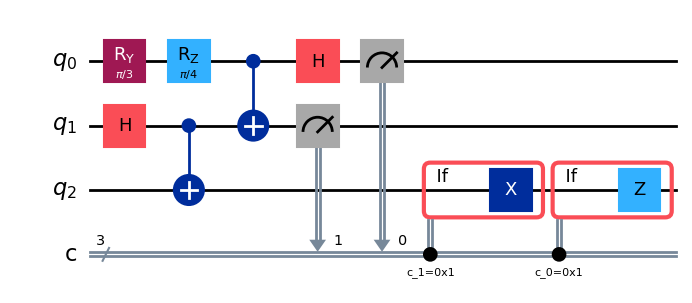

In [18]:
display(qc.draw('mpl'))

### Step 6: Verification via Uncomputation ($U^\dagger$)

Measuring an arbitrary quantum state directly yields non-deterministic results. To prove Bob holds $|\psi\rangle$ deterministically:
* We apply $U^\dagger = R_y(-\theta) R_z(-\phi)$ to $q_2$.
* Since $U^\dagger U = I$, applying $U^\dagger$ maps $|\psi\rangle$ back to $|0\rangle$.
* If teleportation succeeds, measuring $q_2$ into $c_2$ will return `0` with 100% probability.

In [19]:
# Uncompute payload state on Bob's qubit (q2)
# Apply U_dagger: reverse order and negate angles
qc.rz(-phi, 2)
qc.ry(-theta, 2)

# Measure Bob's qubit (q2) into classical bit 2 (c2)
qc.measure(2, 2)

### Step 7: Execution & Results Analysis

We execute the circuit on `AerSimulator` and parse the output bitstring formatted as `c2 c1 c0`:
* Bits **$c_1 c_0$** (right side) fluctuate randomly across shots (`00`, `01`, `10`, `11`) due to Alice's probabilistic measurements.
* Bit **$c_2$** (leftmost bit) evaluates to **`0` across 100% of the shots**, confirming successful teleportation and deterministic uncomputation.

In [20]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# Load the simulator
simulator = AerSimulator()

# Transpile circuit for backend execution
compiled_circuit = transpile(qc, simulator)

# Execute circuit
job = simulator.run(compiled_circuit, shots=1024)
counts = job.result().get_counts()

# Print output dictionary
print("Measurement Counts:", counts)

Measurement Counts: {'000': 247, '011': 264, '010': 266, '001': 247}


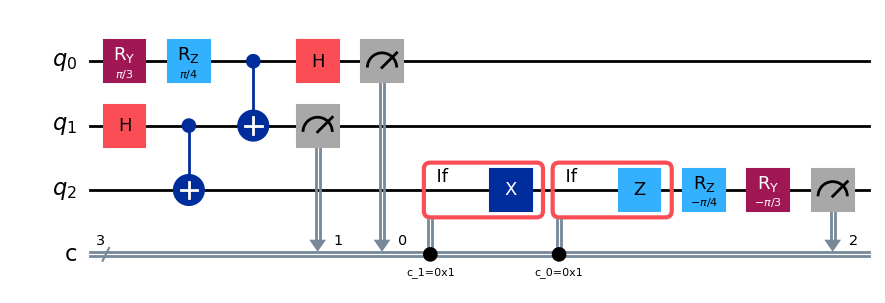

In [23]:
display(qc.draw('mpl'))


### Interpreting Output Results & Verification Proof

The simulation outputs measurement counts formatted as 3-bit classical bitstrings: **`c2 c1 c0`** (ordered right-to-left by Qiskit bit indexing).

* **Alice's Measurement Bits (`c1 c0` - Rightmost 2 Bits):**
  Across 1,024 shots, you will see four distinct outcomes (`000`, `001`, `010`, and `011`), each appearing approximately 25% of the time ($\approx 256$ shots). This distribution is expected—Alice's Bell-basis measurement projects her qubits ($q_0, q_1$) into one of four random states with equal probability.

* **Bob's Verification Bit (`c2` - Leftmost Bit):**
  Despite the random fluctuations in Alice's bits ($c_1 c_0$), the leftmost bit **`c2` evaluates to `0` across 100% of the shots**.

**Why $c_2 = 0$ Mathematically Proves Success:**
1. **State Recovery:** After applying Phase 5 dynamic corrections, Bob's qubit $q_2$ is in the exact target state $|\psi\rangle = U|0\rangle$.
2. **Uncomputation Transformation:** In Phase 6, Bob applies $U^\dagger$ to $q_2$.
3. **Identity Collapse:** 
   $$U^\dagger |\psi\rangle = U^\dagger (U |0\rangle) = (U^\dagger U) |0\rangle = I |0\rangle = |0\rangle$$

Because measuring $|0\rangle$ in the computational basis deterministically yields `0`, a 100% count on **`c2 = 0`** confirms that $q_2$ held the exact state $|\psi\rangle$ prior to uncomputation.


### Key Takeaways

* **State-Agnostic Engine ($U$):** The protocol works for *any* arbitrary state $|\psi\rangle = U|0\rangle$. Replacing $R_y/R_z$ with any unitary $U \in SU(2)$ leaves the core teleportation logic (Steps 3–5) completely unchanged.
* **No-Cloning Preserved:** Alice's Bell measurement destroys her original state on $q_0$, ensuring the qubit is transferred rather than copied.
* **Classical Speed Limit:** Bob cannot recover $|\psi\rangle$ until Alice sends her 2 measurement bits, enforcing no faster-than-light communication.
* **Deterministic Verification ($U^\dagger$):** Applying $U^\dagger$ shifts Bob's qubit ($q_2$) back to $|0\rangle$ with 100% probability, proving exact state reconstruction without full state tomography.